<a href="https://colab.research.google.com/github/Devisri1103/Customer-Support-Ticket-Classifier/blob/main/ML_project_CustomerSupport_TicketClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Idea**

**AI-Powered Customer Support Ticket Classification System** is a machine learning project that automatically categorizes customer support tickets based on their content. Organizations receive thousands of support tickets daily, and manually identifying whether a ticket is an Incident, Request, Problem, or Change can be time-consuming and error-prone.

This project uses Natural Language Processing (NLP) and Machine Learning to analyze the ticket's subject and description, understand the issue being reported, and automatically assign it to the correct ticket category. By automating ticket classification, support teams can route tickets faster, reduce manual effort, and improve response times.

# **Project Description**

The system takes the **subject** and **body** of a customer support ticket as input. The textual information is preprocessed and converted into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)**. **A Logistic Regression** machine learning model is then trained on historical support tickets to learn patterns associated with different ticket types.

When a new ticket is submitted, the trained model predicts whether the ticket belongs to one of the following categories:

*  Incident
*  Request
*  Problem
*  Change

The project demonstrates the practical application of **Natural Language Processing, text classification, feature engineering, and supervised machine learning** in solving a real-world business problem. The solution helps organizations streamline support operations, improve ticket routing accuracy, and enhance overall customer service efficiency.


**Dataset Understanding**

* 2125+ tickets
* 10 support categories
* Subject and body fields


**Load Dataset**

In [5]:
import pandas as pd

df=pd.read_csv("/content/dataset-tickets-multi-lang3-4k.csv")

df.head()

,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,NaN
3,Urgent Assistance Required: AWS Service,"Dear IT Services Support Team, \n\nI am reachi...","Dear <name>,\n\nThank you for reaching out reg...",Request,IT Support,high,en,IT Services,IT Support,Urgent Issue,Service Notification,Cloud Services,Problem Resolution,Technical Guidance,Performance Tuning,NaN,NaN
4,Problème d'affichage de MacBook Air,Cher équipe de support du magasin en ligne Tec...,"Cher <name>,\n\nMerci de nous avoir contactés ...",Incident,Product Support,low,fr,Tech Online Store,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN,NaN


**Data Exploration**

In [6]:
print(df.shape)

(4000, 17)


In [7]:
print(df.columns)

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'business_type', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8', 'tag_9'],
      dtype='object')


In [8]:
df.head()


,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,NaN
3,Urgent Assistance Required: AWS Service,"Dear IT Services Support Team, \n\nI am reachi...","Dear <name>,\n\nThank you for reaching out reg...",Request,IT Support,high,en,IT Services,IT Support,Urgent Issue,Service Notification,Cloud Services,Problem Resolution,Technical Guidance,Performance Tuning,NaN,NaN
4,Problème d'affichage de MacBook Air,Cher équipe de support du magasin en ligne Tec...,"Cher <name>,\n\nMerci de nous avoir contactés ...",Incident,Product Support,low,fr,Tech Online Store,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN,NaN


In [9]:
df.isnull().sum()

,0
subject,467
body,1
answer,0
type,0
queue,0
priority,0
language,0
business_type,0
tag_1,0
tag_2,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject        3533 non-null   object 
 1   body           3999 non-null   object 
 2   answer         4000 non-null   object 
 3   type           4000 non-null   object 
 4   queue          4000 non-null   object 
 5   priority       4000 non-null   object 
 6   language       4000 non-null   object 
 7   business_type  4000 non-null   object 
 8   tag_1          4000 non-null   object 
 9   tag_2          4000 non-null   object 
 10  tag_3          4000 non-null   object 
 11  tag_4          3999 non-null   object 
 12  tag_5          3363 non-null   object 
 13  tag_6          2181 non-null   object 
 14  tag_7          1045 non-null   object 
 15  tag_8          269 non-null    object 
 16  tag_9          0 non-null      float64
dtypes: float64(1), object(16)
memory usage: 531.4+ KB


In [11]:
print(df.columns)

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'business_type', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8', 'tag_9'],
      dtype='object')


**Data Preprocessing**

* Combine subject + body
* Handle missing values
* TF-IDF feature extraction

**Combine Subject and Body**

In [12]:
df["text"] = df["subject"].fillna('') + " " + df["body"].fillna('')

df[["text","queue"]].head()

,text,queue
0,Problema crítico del servidor requiere atenció...,Technical Support
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310...,Customer Service
2,Erro na Autocompletação de Código do IntelliJ ...,Technical Support
3,Urgent Assistance Required: AWS Service Dear I...,IT Support
4,Problème d'affichage de MacBook Air Cher équip...,Product Support


**Check Categories**

In [13]:
print(df["queue"].value_counts())

queue
Technical Support                  1317
Product Support                     690
Customer Service                    627
IT Support                          445
Billing and Payments                338
Returns and Exchanges               197
Service Outages and Maintenance     141
Sales and Pre-Sales                 137
General Inquiry                      55
Human Resources                      53
Name: count, dtype: int64


**Remove Missing Values**

In [14]:
df = df.dropna(subset=["text","queue"])

print(df.shape)

(4000, 18)


**Define Features and Labels**

In [15]:
X = df["text"]

y = df["queue"]

**Train-Test Split**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**TF-IDF Vectorization**

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

**Train Logistic Regression**

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

**Predictions**

In [19]:
y_pred = model.predict(X_test_tfidf)

**Accuracy**

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.50375


**Detailed Metrics**

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                 precision    recall  f1-score   support

           Billing and Payments       0.91      0.85      0.88        68
               Customer Service       0.45      0.38      0.41       125
                General Inquiry       0.00      0.00      0.00        11
                Human Resources       0.00      0.00      0.00        11
                     IT Support       0.36      0.06      0.10        89
                Product Support       0.41      0.43      0.42       138
          Returns and Exchanges       0.83      0.51      0.63        39
            Sales and Pre-Sales       1.00      0.04      0.07        27
Service Outages and Maintenance       1.00      0.07      0.13        28
              Technical Support       0.47      0.80      0.60       264

                       accuracy                           0.50       800
                      macro avg       0.54      0.31      0.32       800
                   weighted avg       0.52      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Confusion Matrix**

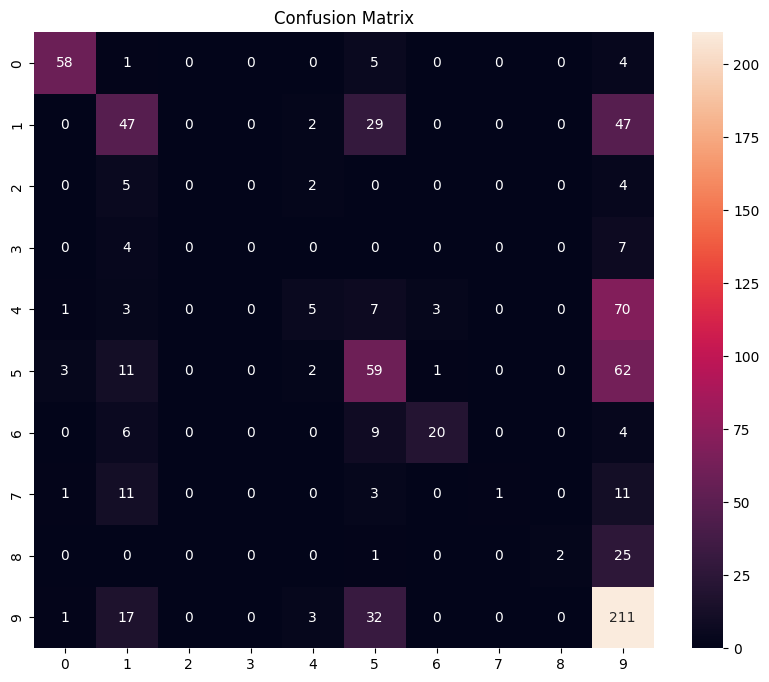

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

**Test Custom Ticket**

In [23]:
ticket = """
Unable to login after password reset.
Password reset email is not arriving.
"""

vector = tfidf.transform([ticket])

prediction = model.predict(vector)

print("Predicted Queue:", prediction[0])

Predicted Queue: Technical Support


In [24]:
ticket="""
login issues
"""

vector = tfidf.transform([ticket])

prediction = model.predict(vector)

print("Predicted Queue:", prediction[0])

Predicted Queue: Technical Support


In [25]:
ticket = """
Passwort zurücksetzen funktioniert nicht.
Kann mich nicht anmelden.
"""

vector = tfidf.transform([ticket])

prediction = model.predict(vector)

print(prediction[0])

Technical Support


In [26]:
ticket = """
Payment failed but amount deducted.
"""

vector = tfidf.transform([ticket])

prediction = model.predict(vector)

print("Predicted Queue:", prediction[0])

Predicted Queue: Billing and Payments


**Predict Priority**

In [27]:
y = df["priority"]

In [28]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

In [ ]:
print(df["queue"].value_counts())

queue
Technical Support                  1317
Product Support                     690
Customer Service                    627
IT Support                          445
Billing and Payments                338
Returns and Exchanges               197
Service Outages and Maintenance     141
Sales and Pre-Sales                 137
General Inquiry                      55
Human Resources                      53
Name: count, dtype: int64


**Check Baseline Accuracy**


In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.50375


**Model Building**


*   Logistic Regression
*   Naive Bayes
*   Random Forest


**Model 1: Logistic Regression**

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score

print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))

Logistic Regression: 0.50375


**Model 2: Naive Bayes**

In [31]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

print("Naive Bayes:",
      accuracy_score(y_test, nb_pred))

Naive Bayes: 0.3875


**Model 3: Random Forest**

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

rf_pred = rf.predict(X_test_tfidf)

print("Random Forest:",
      accuracy_score(y_test, rf_pred))

Random Forest: 0.53625


**Evaluation**

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix

                 Model  Accuracy
0  Logistic Regression   0.50375
1          Naive Bayes   0.38750
2        Random Forest   0.53625


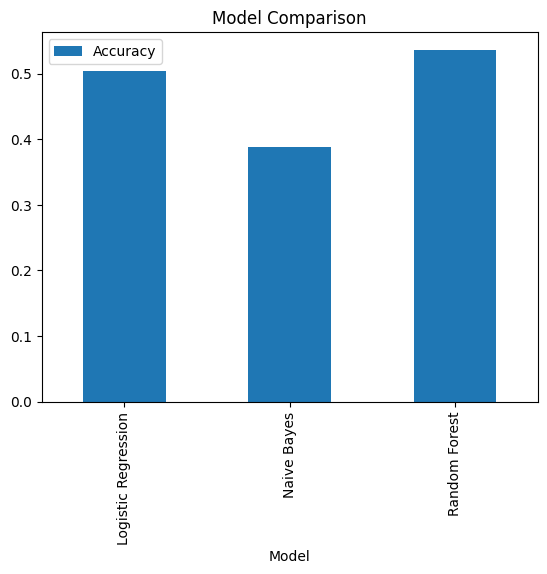

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

results.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title("Model Comparison")
plt.show()

**Results**

Three machine learning models—Logistic Regression, Naive Bayes, and Random Forest—were trained and evaluated for customer support ticket classification. Random Forest achieved the highest accuracy of 53.63%, outperforming Logistic Regression (50.38%) and Naive Bayes (38.75%).

The model successfully classified support tickets into different business categories based on their subject and description. Random Forest was selected as the final model because it provided the best overall performance on the dataset.
